# Part 1 — Baseline: study the environment, compare PPO vs DQN, save the best model

This is the entry-point notebook. It (1) **studies and explains** `highway-env`, (2) trains **PPO** and **DQN** on the same seeds, (3) evaluates and **compares** them, (4) **picks the best** model by an explicit rule, and (5) saves the **best checkpoint + `part1_best.mp4`** to Google Drive.

Function-only `.py` modules are imported and driven from here; every parameter lives in `configs/highway.yaml`.

## 1. Setup — mount Drive, token, clone, install

In [1]:
import os, warnings, logging
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message=r'.*Gym has been unmaintained.*')
logging.getLogger('gym').setLevel(logging.ERROR)

from google.colab import drive
drive.mount('/content/drive')

TOKEN = None
try:
    from google.colab import userdata
    TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    TOKEN = None
if not TOKEN:
    import getpass
    TOKEN = getpass.getpass('GitHub token (input hidden): ')
assert TOKEN, 'No token provided.'
os.environ['GITHUB_TOKEN'] = TOKEN
print('Token loaded (not displayed).')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Token loaded (not displayed).


In [2]:
%%bash
set -e
GH_USER=silvergjeka22
REPO=nesy-highway-driving
curl -fsSL -H "Authorization: token ${GITHUB_TOKEN}" \
  "https://raw.githubusercontent.com/${GH_USER}/${REPO}/main/bash/setup_colab.sh" \
  -o /content/setup_colab.sh
bash /content/setup_colab.sh

# Belt-and-suspenders: keep NumPy on 2.x even if a cached requirements pinned <2,
# otherwise the kernel throws "numpy.dtype size changed" on import below.
pip install -q -U "numpy>=2.0,<3"


==> Repo:       silvergjeka22/nesy-highway-driving (private)
==> Workdir:    /content/nesy-highway-driving
==> Drive root: /content/drive/MyDrive/nesy-highway-driving
==> Repo exists; pulling latest.
Updating 4827601..7ae1b70
Fast-forward
 bash/setup_colab.sh               |  6 +++++
 notebooks/colab_1_baseline.ipynb  | 26 +++++++++++++++++++-
 notebooks/colab_2_nesy.ipynb      | 51 +++++++++++++++++++++++++++++++++------
 notebooks/colab_3_metadrive.ipynb | 43 +++++++++++++++++++++++++++++----
 notebooks/colab_4_race.ipynb      | 47 +++++++++++++++++++++++++++++++-----
 requirements.txt                  |  4 ++-
 6 files changed, 157 insertions(+), 20 deletions(-)
==> Installing xvfb (headless rendering).
==> Installing requirements.
==> Enforcing a NumPy 2.x build.
==> Creating Drive results folders.
==> Done.
    Add the repo to sys.path in Python:  import sys; sys.path.insert(0, '/content/nesy-highway-driving')
    Results will mirror to:              /content/drive/MyDrive/nesy-hi

From https://github.com/silvergjeka22/nesy-highway-driving
   4827601..7ae1b70  main       -> origin/main


In [3]:
# --- NumPy self-heal (fixes the "numpy.dtype size changed ... Expected 96, got 88"
#     ABI error). A NumPy<2 downgrade leaves a build that is incompatible with
#     Colab's NumPy-2-compiled wheels. setup_colab.sh now keeps NumPy on 2.x; if the
#     kernel already loaded a broken NumPy, restart ONCE so the clean build loads.
#     Guarded by a sentinel file so it never loops. ---
import os
try:
    import numpy as _np
    _ = _np.random.Generator            # touches the C-extension that trips on ABI mismatch
    _np_broken = _np.__version__.split('.')[0] != '2'
except Exception:
    _np_broken = True
if _np_broken and not os.path.exists('/content/.numpy_restarted'):
    open('/content/.numpy_restarted', 'w').close()
    print('NumPy was stale; restarting the runtime once. '
          'After it restarts, run Runtime > Run all again.')
    import sys; sys.stdout.flush()
    os.kill(os.getpid(), 9)
# ---------------------------------------------------------------------------

import sys
sys.path.insert(0, '/content/nesy-highway-driving')
%cd /content/nesy-highway-driving
from utils import load_config, drive_path, save_json
cfg = load_config('configs/highway.yaml')

# Headless rendering so every part can save its .mp4 to Drive.
from pyvirtualdisplay import Display
_display = Display(visible=0, size=(900, 480)); _display.start()
print('virtual display started; config loaded')

/content/nesy-highway-driving
virtual display started; config loaded


## 2. Study & explain the environment

**`highway-env`** is a lightweight driving simulator with surrounding traffic. We use the **`highway-v0`** scenario with **discrete tactical meta-actions** — the agent picks a manoeuvre and a low-level controller handles steering/throttle. This is the deliberate hinge for Part 2: symbolic rules are naturally written over *manoeuvres*.

- **Action space (`DiscreteMetaAction`):** `LANE_LEFT, IDLE, LANE_RIGHT, FASTER, SLOWER`.
- **Observation (`Kinematics`):** ego + the `vehicles_count`−1 nearest vehicles as `[presence, x, y, vx, vy]`, ego-relative, normalised, fixed shape.
- **Reward:** native speed/lane-keeping − collision, **plus light shaping** (small bonus per car passed, small off-road penalty). Kept light so it does not confound the Part-2 NeSy comparison.

Below: the printed observation, a rendered frame, and a short random-policy clip so you can see the task before any learning.

observation shape: (5, 5)    (rows = ego + nearest vehicles)
features = [presence, x, y, vx, vy], ego-relative + normalised:
[[ 1.     0.895  0.     0.312  0.   ]
 [ 1.     0.112  0.75  -0.018  0.   ]
 [ 1.     0.225  0.5   -0.021  0.   ]
 [ 1.     0.327  0.75  -0.033  0.   ]
 [ 1.     0.433  0.75  -0.019  0.   ]]

action meanings: {'type': 'DiscreteMetaAction'}


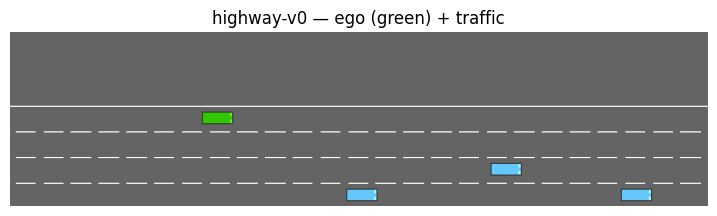

In [4]:
import matplotlib.pyplot as plt
from envs.highway_factory import make_env

env = make_env(cfg, render=True)
obs, info = env.reset(seed=cfg['seed'])
print('observation shape:', obs.shape, '   (rows = ego + nearest vehicles)')
print('features = [presence, x, y, vx, vy], ego-relative + normalised:')
print(obs.round(3))
print('\naction meanings:', cfg['env']['config']['action'])

frame = env.render()
plt.figure(figsize=(9, 3)); plt.imshow(frame); plt.axis('off')
plt.title('highway-v0 — ego (green) + traffic'); plt.show()
env.close()

In [5]:
# Random-policy rollout clip (the task before any learning).
from eval.evaluate import record_random_video
rnd = record_random_video(cfg, drive_path(cfg, 'videos', 'part1_random.mp4'), n_steps=60)
print('random rollout video saved to:', rnd)

random rollout video saved to: /content/drive/MyDrive/nesy-highway-driving/videos/part1_random.mp4


## 3. Train both baselines (same env, same seeds)

| Algorithm | Type | Why |
|---|---|---|
| **PPO** | On-policy policy-gradient | Recommended; on-policy avoids replaying stale noisy transitions; clipped objective tolerates shaping; clean credit assignment for multi-step overtakes. |
| **DQN** | Off-policy value-based | Second baseline; more sample-efficient on discrete actions but more brittle in noisy traffic. |

(This is the **RL half of Lab 5**, before any safety is added.)

In [ ]:
from agents.baselines import train_ppo, train_dqn
ppo_model = train_ppo(cfg)   # -> checkpoints/ppo.zip
dqn_model = train_dqn(cfg)   # -> checkpoints/dqn.zip

In [ ]:
# --- Training curves: PPO vs DQN (logged to metrics/curves/<algo>/progress.csv) ---
from eval.plots import plot_training_curves
plot_training_curves(cfg, tags=('ppo', 'dqn'))

## 4. Evaluate both on the same held-out seeds

In [ ]:
from eval.evaluate import evaluate
m_ppo = evaluate(ppo_model, cfg); save_json(m_ppo, drive_path(cfg, 'metrics', 'ppo.json'))
m_dqn = evaluate(dqn_model, cfg); save_json(m_dqn, drive_path(cfg, 'metrics', 'dqn.json'))
print('PPO:', m_ppo['summary'])
print('DQN:', m_dqn['summary'])

In [ ]:
import pandas as pd
def row(name, m):
    s = m['summary']
    return {'algo': name, 'crash_rate': round(s['crash_rate'], 3),
            'on_road_%': f"{s['on_road_pct']['mean']:.1f}\u00b1{s['on_road_pct']['std']:.1f}",
            'overtakes': f"{s['overtakes']['mean']:.2f}\u00b1{s['overtakes']['std']:.2f}",
            'return': f"{s['return']['mean']:.2f}\u00b1{s['return']['std']:.2f}",
            'length': f"{s['length']['mean']:.1f}\u00b1{s['length']['std']:.1f}"}
pd.DataFrame([row('PPO', m_ppo), row('DQN', m_dqn)])

In [ ]:
# --- Evaluation comparison: crash rate, return, overtakes, on-road % ---
from eval.plots import plot_eval_comparison
plot_eval_comparison({'PPO': m_ppo, 'DQN': m_dqn}, cfg, save_as='eval_compare.png')

## 5. Pick the best model + save it (and `part1_best.mp4`) to Drive
Selection rule (from `configs/highway.yaml` → `select:`): among models within `within_return_pct` of the top mean return, choose the **lowest crash rate** (safety-first). The chosen tag is recorded so Parts 2 and 4 load exactly this checkpoint.

In [ ]:
from agents.baselines import select_best
from eval.evaluate import record_video

candidates = {'ppo': {'model': ppo_model, 'metrics': m_ppo},
              'dqn': {'model': dqn_model, 'metrics': m_dqn}}
best_model, tag = select_best(candidates, cfg)
print('Selected best model:', tag)

best_model.save(drive_path(cfg, 'checkpoints', f'part1_best_{tag}.zip'))
save_json({'tag': tag}, drive_path(cfg, 'metrics', 'part1_best.json'))
video = record_video(best_model, cfg, drive_path(cfg, 'videos', 'part1_best.mp4'))
print('Saved: checkpoints/part1_best_%s.zip  +  %s' % (tag, video))

**Exit criterion.** Best checkpoint on Drive (`part1_best_{tag}.zip`), the PPO-vs-DQN table, a documented selection rule, and **`part1_best.mp4`**. Next: `colab_2_nesy.ipynb` loads exactly this checkpoint.